**Name**: BABATUNDE MUBARAQ ADEBAYO <br>
**Course Enrollment**: DATA SCIENCE <br>
**Assignment**: C7 TASK 3

# Pizza Place Sales Analysis

## Task 3

### Project Overview

This project analyzes one year of sales data from a fictitious pizza restaurant.

The dataset contains four CSV files:

- Orders
- Order Details
- Pizzas
- Pizza Types

The objective of this analysis is to answer important business questions about the restaurant's sales performance using Python, Pandas, and data visualization.

The datasets will first be merged into a single DataFrame before performing exploratory data analysis (EDA).

In [43]:
# Import the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Improve plot appearance
sns.set_style("whitegrid")

## Step 1: Load the Datasets

The first step is to load the four CSV files into Pandas DataFrames.

Each dataset contains different information about the pizza sales, so they will later be merged into one complete dataset.

In [44]:
orders = pd.read_csv(r"C:\Users\USER\Documents\Cohort 7 Notebooks\orders.csv")

order_details = pd.read_csv(r"C:\Users\USER\Documents\Cohort 7 Notebooks\order_details.csv")

pizzas = pd.read_csv(r"C:\Users\USER\Documents\Cohort 7 Notebooks\pizzas.csv")

pizza_types = pd.read_csv(r"C:\Users\USER\Documents\Cohort 7 Notebooks\pizza_types.csv", encoding="latin1")

## Step 2: Preview the Datasets

After loading the datasets, we inspect the first few rows of each table to understand the available columns and the structure of the data.

In [45]:
orders.head()

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30


In [46]:
order_details.head()

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [47]:
pizzas.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [48]:
pizza_types.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


## Step 3: Check the Shape of Each Dataset

The shape of a dataset tells us the number of rows and columns it contains.

In [49]:
print("Orders:", orders.shape)

print("Order Details:", order_details.shape)

print("Pizzas:", pizzas.shape)

print("Pizza Types:", pizza_types.shape)

Orders: (21350, 3)
Order Details: (48620, 4)
Pizzas: (96, 4)
Pizza Types: (32, 4)


## Step 4: Check Data Types and Missing Values

Before analysis, it is important to inspect the datasets for missing values and verify the data types of each column.

In [50]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21350 entries, 0 to 21349
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   order_id  21350 non-null  int64 
 1   date      21350 non-null  object
 2   time      21350 non-null  object
dtypes: int64(1), object(2)
memory usage: 500.5+ KB


In [51]:
orders.isnull().sum()

order_id    0
date        0
time        0
dtype: int64

In [52]:
order_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_details_id  48620 non-null  int64 
 1   order_id          48620 non-null  int64 
 2   pizza_id          48620 non-null  object
 3   quantity          48620 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [53]:
order_details.isnull().sum()

order_details_id    0
order_id            0
pizza_id            0
quantity            0
dtype: int64

In [54]:
pizzas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pizza_id       96 non-null     object 
 1   pizza_type_id  96 non-null     object 
 2   size           96 non-null     object 
 3   price          96 non-null     float64
dtypes: float64(1), object(3)
memory usage: 3.1+ KB


In [55]:
pizzas.isnull().sum()

pizza_id         0
pizza_type_id    0
size             0
price            0
dtype: int64

In [56]:
pizza_types.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   pizza_type_id  32 non-null     object
 1   name           32 non-null     object
 2   category       32 non-null     object
 3   ingredients    32 non-null     object
dtypes: object(4)
memory usage: 1.1+ KB


In [57]:
pizza_types.isnull().sum()

pizza_type_id    0
name             0
category         0
ingredients      0
dtype: int64

## Step 5: Merge the Datasets

The information required for the analysis is spread across four different tables.

To simplify the analysis, the datasets are merged into one complete DataFrame using their common columns.

In [58]:
df = order_details.merge(
    orders,
    on="order_id"
)

df = df.merge(
    pizzas,
    on="pizza_id"
)

df = df.merge(
    pizza_types,
    on="pizza_type_id"
)

## Step 6: Create a Revenue Column

The dataset does not contain a revenue column.

Revenue is calculated by multiplying the quantity sold by the selling price.

In [59]:
df["revenue"] = df["quantity"] * df["price"]

df.head()

,order_details_id,order_id,pizza_id,quantity,date,time,pizza_type_id,size,price,name,category,ingredients,revenue
0,1,1,hawaiian_m,1,2015-01-01,11:38:36,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25
1,2,2,classic_dlx_m,1,2015-01-01,11:57:40,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00
2,3,2,five_cheese_l,1,2015-01-01,11:57:40,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50
3,4,2,ital_supr_l,1,2015-01-01,11:57:40,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75
4,5,2,mexicana_m,1,2015-01-01,11:57:40,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00


# Question 1

## What is the Total Revenue?

The total revenue represents the total income generated from all pizza sales during the year.

In [60]:
total_revenue = df["revenue"].sum()

print(f"Total Revenue: ${total_revenue:.2f}")

Total Revenue: $817860.05


### Insight

The pizza restaurant generated approximately **$817,860.05** in total revenue during the year.

# Question 2

## Find the Total Quantity Sold

In [61]:
total_quantity = df["quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 49574


### Insight

A total of **49,574 pizzas** were sold during the year.

# Question 3

## Find the Total Number of Orders

In [62]:
total_orders = df["order_id"].nunique()

print("Total Orders:", total_orders)

Total Orders: 21350


### Insight

The restaurant received **21,350 customer orders** during the year.

# Question 4

## How Many Pizza Types Are Sold?

In [63]:
pizza_count = df["name"].nunique()

print("Number of Pizza Types:", pizza_count)

Number of Pizza Types: 32


### Insight

The restaurant offers **32 different pizza types** on its menu.

# Question 5

## What is the Average Pizza Price?

In [64]:
average_price = df["price"].mean()

print(f"Average Pizza Price: ${average_price:.2f}")

Average Pizza Price: $16.49


### Insight

The average selling price of a pizza is approximately **$16.49**.

# Question 6

## What are the Peak Hours of Sales?

This analysis aims to identify the hours of the day when the restaurant receives the highest number of orders.

Knowing the busiest hours helps management schedule staff efficiently and prepare enough ingredients during peak periods.

In [65]:
# Convert the time column to datetime format
df["time"] = pd.to_datetime(df["time"])

# Extract the hour from the time column
df["hour"] = df["time"].dt.hour

# Count the number of orders for each hour
hourly_orders = df.groupby("hour")["order_id"].count()

hourly_orders

C:\Users\USER\AppData\Local\Temp\ipykernel_9464\455782239.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"])


hour
9        4
10      17
11    2672
12    6543
13    6203
14    3521
15    3170
16    4185
17    5143
18    5359
19    4350
20    3487
21    2528
22    1370
23      68
Name: order_id, dtype: int64

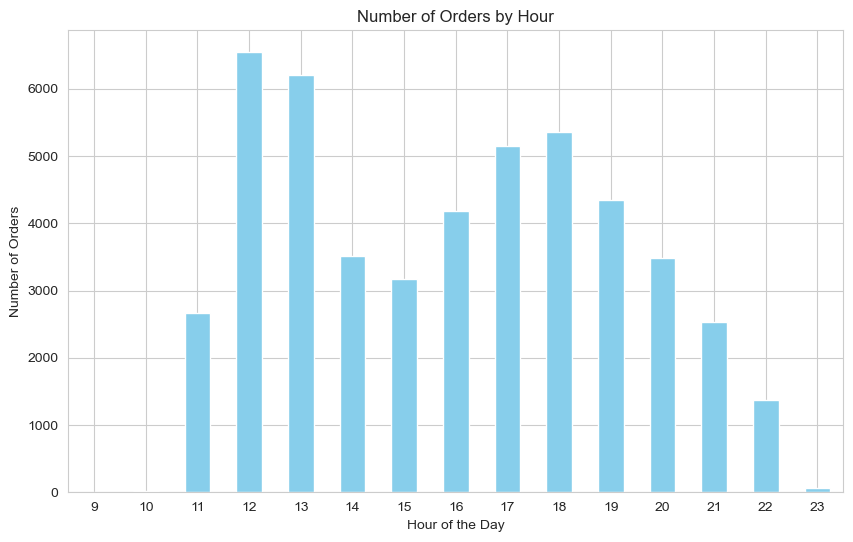

In [66]:
# Plot the peak sales hours

plt.figure(figsize=(10,6))

hourly_orders.plot(kind="bar", color="skyblue")

plt.title("Number of Orders by Hour")

plt.xlabel("Hour of the Day")

plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.show()

### Insight

The bar chart shows the distribution of customer orders throughout the day.

The restaurant experiences the highest number of orders during lunch and dinner hours, suggesting these are the busiest periods of operation. Management should ensure sufficient staff and inventory are available during these peak hours.

# Question 7

## Find the Total Sales Made on Each Day of the Week

This analysis calculates the total revenue generated on each day of the week to identify the busiest sales day.

In [67]:
# Convert the date column to datetime format
df["date"] = pd.to_datetime(df["date"])

# Extract the day of the week
df["day"] = df["date"].dt.day_name()

# Calculate total revenue for each day
weekday_sales = df.groupby("day")["revenue"].sum()

# Arrange the days in order
days = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

weekday_sales = weekday_sales.reindex(days)

weekday_sales

day
Monday       107329.55
Tuesday      114133.80
Wednesday    114408.40
Thursday     123528.50
Friday       136073.90
Saturday     123182.40
Sunday        99203.50
Name: revenue, dtype: float64

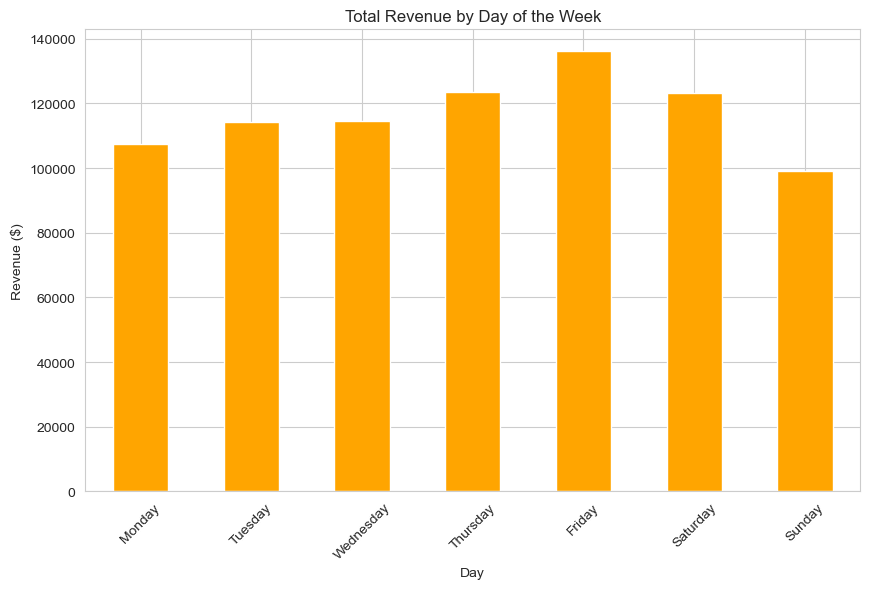

In [68]:
# Plot the sales by weekday

plt.figure(figsize=(10,6))

weekday_sales.plot(kind="bar", color="orange")

plt.title("Total Revenue by Day of the Week")

plt.xlabel("Day")

plt.ylabel("Revenue ($)")

plt.xticks(rotation=45)

plt.show()

In [69]:
# Find the day with the highest sales

best_day = weekday_sales.idxmax()

best_day_sales = weekday_sales.max()

print("Highest Sales Day:", best_day)

print("Revenue: $", round(best_day_sales,2))

Highest Sales Day: Friday
Revenue: $ 136073.9


### Insight

The chart shows that sales vary across the week.

The day with the highest revenue is **Friday**.

This suggests that customer demand is highest on this day, making it an ideal time for promotions and ensuring adequate staffing.

# Question 8

## Find the Top 5 Bestselling Pizzas

This analysis identifies the pizzas with the highest quantities sold during the year.

In [70]:
# Calculate the top five bestselling pizzas

top5 = df.groupby("name")["quantity"].sum().sort_values(ascending=False).head(5)

top5

name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64

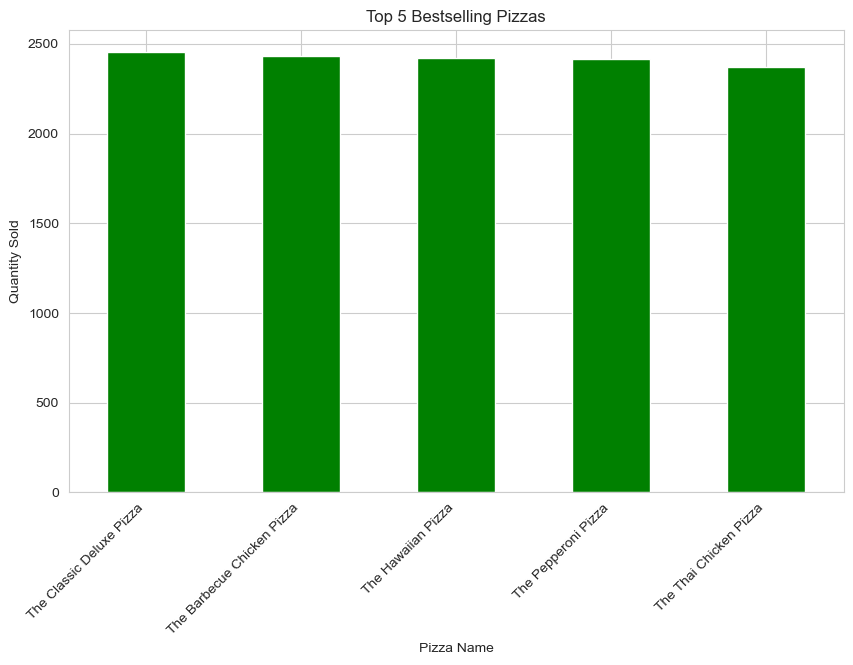

In [71]:
# Plot the top 5 pizzas

plt.figure(figsize=(10,6))

top5.plot(kind="bar", color="green")

plt.title("Top 5 Bestselling Pizzas")

plt.xlabel("Pizza Name")

plt.ylabel("Quantity Sold")

plt.xticks(rotation=45, ha="right")

plt.show()

### Insight

The chart identifies the five pizzas that generated the highest sales volume.

These pizzas are the restaurant's best-performing products and should remain well-stocked. Management may also consider promoting similar pizza varieties to increase overall sales.

# Question 9

## Find the Sales Made in Each Month

This analysis examines monthly sales performance to identify seasonal trends throughout the year.

In [72]:
# Extract the month name
df["month"] = df["date"].dt.month_name()

# Calculate monthly revenue
monthly_sales = df.groupby("month")["revenue"].sum()

# Arrange the months correctly
months = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = monthly_sales.reindex(months)

monthly_sales

month
January      69793.30
February     65159.60
March        70397.10
April        68736.80
May          71402.75
June         68230.20
July         72557.90
August       68278.25
September    64180.05
October      64027.60
November     70395.35
December     64701.15
Name: revenue, dtype: float64

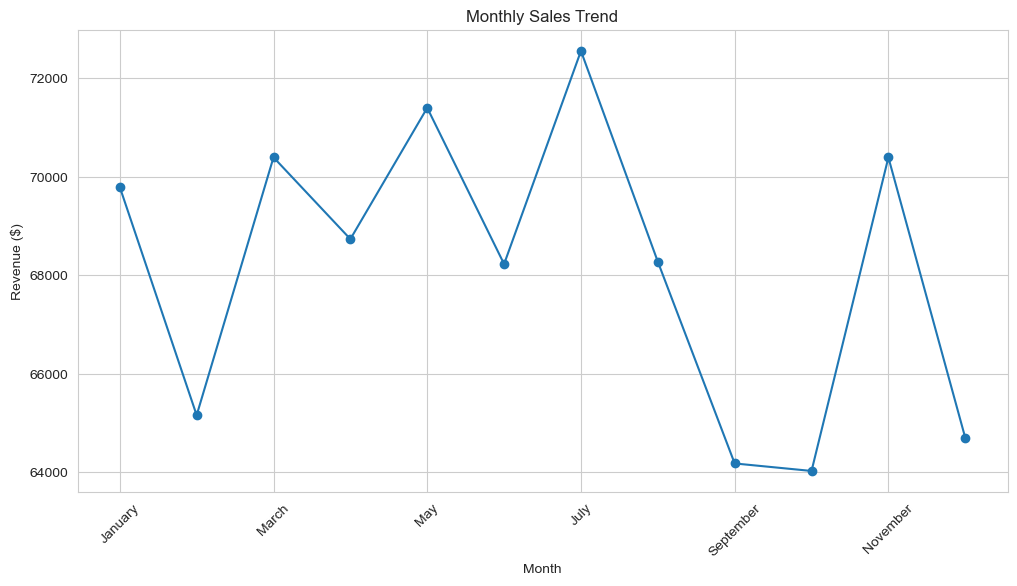

In [73]:
# Plot monthly sales

plt.figure(figsize=(12,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Revenue ($)")

plt.xticks(rotation=45)

plt.show()

### Insight

The line chart illustrates how sales changed throughout the year.

By examining the trend, we can identify months with the highest and lowest revenue. These patterns can help management plan marketing campaigns, staffing, and inventory according to seasonal demand.

# Question 10

## Are There Pizza Types That Are Not Performing Well?

This analysis identifies the least-selling pizzas on the menu based on quantity sold.

In [74]:
# Find the least-selling pizzas

least_selling = df.groupby("name")["quantity"].sum().sort_values().head(10)

least_selling

name
The Brie Carre Pizza            490
The Mediterranean Pizza         934
The Calabrese Pizza             937
The Spinach Supreme Pizza       950
The Soppressata Pizza           961
The Spinach Pesto Pizza         970
The Chicken Pesto Pizza         973
The Italian Vegetables Pizza    981
The Chicken Alfredo Pizza       987
The Green Garden Pizza          997
Name: quantity, dtype: int64

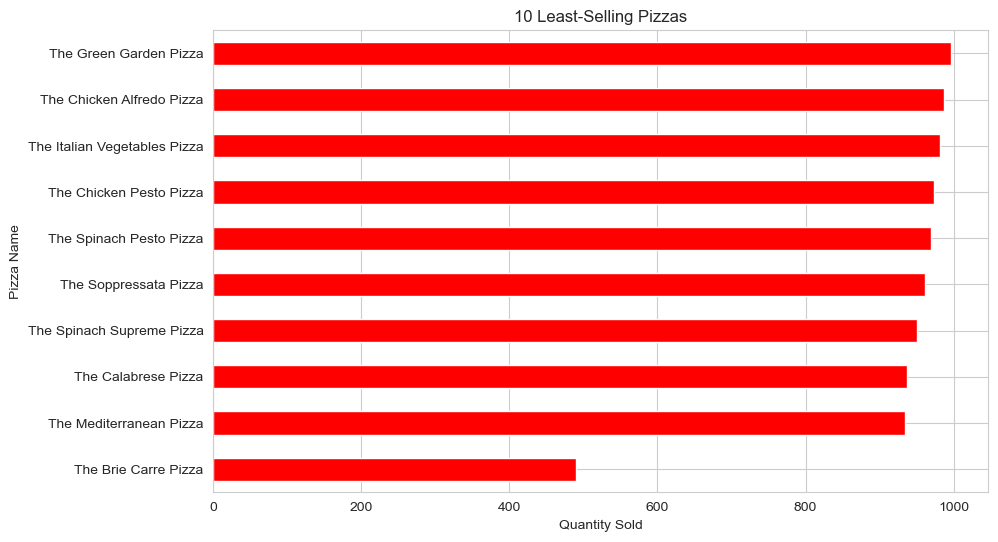

In [75]:
# Plot the least-selling pizzas

plt.figure(figsize=(10,6))

least_selling.plot(kind="barh", color="red")

plt.title("10 Least-Selling Pizzas")

plt.xlabel("Quantity Sold")

plt.ylabel("Pizza Name")

plt.show()

### Insight

The chart shows the pizzas with the lowest sales throughout the year.

These pizzas may require further investigation to determine why they are underperforming. Management could consider revising recipes, adjusting prices, improving marketing efforts, or removing consistently low-performing items from the menu.

# Additional Analysis

## Revenue by Pizza Category

In addition to the required questions, this analysis examines which pizza categories contribute the most revenue.

In [76]:
category_sales = df.groupby("category")["revenue"].sum().sort_values(ascending=False)

category_sales

category
Classic    220053.10
Supreme    208197.00
Chicken    195919.50
Veggie     193690.45
Name: revenue, dtype: float64

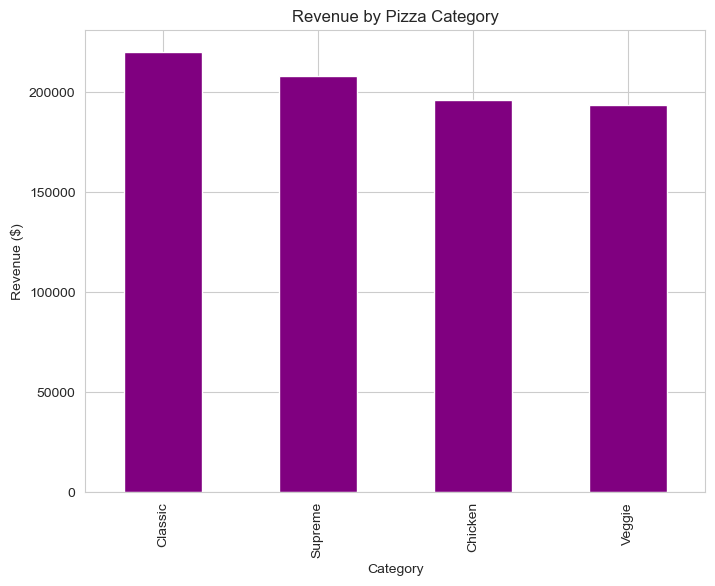

In [77]:
plt.figure(figsize=(8,6))

category_sales.plot(kind="bar", color="purple")

plt.title("Revenue by Pizza Category")

plt.xlabel("Category")

plt.ylabel("Revenue ($)")

plt.show()

### Insight

This analysis highlights the contribution of each pizza category to total revenue.

The highest-performing category generates the largest share of sales and represents an important part of the restaurant's business.

# Additional Analysis

## Revenue by Pizza Size

This analysis determines which pizza sizes contribute the most revenue.

In [78]:
size_sales = df.groupby("size")["revenue"].sum()

size_sales

size
L      375318.70
M      249382.25
S      178076.50
XL      14076.00
XXL      1006.60
Name: revenue, dtype: float64

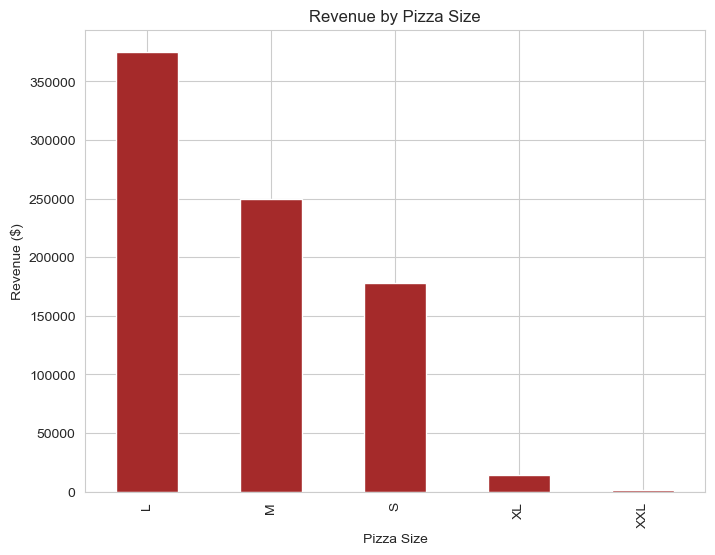

In [79]:
plt.figure(figsize=(8,6))

size_sales.plot(kind="bar", color="brown")

plt.title("Revenue by Pizza Size")

plt.xlabel("Pizza Size")

plt.ylabel("Revenue ($)")

plt.show()

In [80]:
# Calculate the average order value

average_order_value = total_revenue / total_orders

print(f"Average Order Value: ${average_order_value:.2f}")

Average Order Value: $38.31


### Insight

The average order value represents the average amount spent by a customer per order.

This metric helps the restaurant understand customer spending behavior and can be used to evaluate promotional strategies aimed at increasing sales.

# Conclusion

This project analyzed one year of pizza sales data to understand customer purchasing patterns and business performance.

The analysis revealed the restaurant's total revenue, total quantity sold, number of orders, peak sales hours, bestselling pizzas, monthly sales trends, and underperforming menu items.

The findings show that customer demand varies by hour, day, and month, providing valuable insights for staffing, inventory management, marketing, and menu optimization.

Overall, this analysis demonstrates how data-driven insights can support better business decisions and improve restaurant performance.